# Day 06：梯度高速公路 —— 为什么跳跃连接真的有效> 🌉 第八周 · ResNet 的深度 · 第 6 天上周我们见证了残差连接的威力：加一条"近道"，深层网络就能正常训练了。但一个关键问题我们还没有回答：**为什么？**为什么 `out = F(x) + x` 这么简单的一行代码，就能解决退化问题？它的底层原理到底是什么？今天，我们要从**梯度的角度**深入理解残差连接——为什么它为梯度开辟了一条"高速公路"。**今天的任务**：1. 理解梯度在深层网络中是如何传播的2. 用代码验证：残差连接让梯度"畅通无阻"3. 从梯度流的角度理解为什么 ResNet 能训练极深网络---

## 1. 历史剧场：梯度消失——深度学习的"慢性毒药"在残差连接出现之前，深度学习面临的最大敌人之一是**梯度消失**。梯度消失的本质是：在反向传播时，梯度从输出层往输入层传递，每经过一层，梯度都可能变小一点。经过几十层后，梯度变得极其微小——靠近输入层的参数几乎收不到任何更新信号，就像"失联"了一样。这就像一个公司的管理链条：

CEO → 副总裁 → 总监 → 经理 → 主管 → 组长 → 员工

如果每经过一级，信息就衰减 50%，那么从 CEO 传到员工时，信息只剩下 1.5%（0.5^6）。员工收到的指令已经面目全非了。残差连接的出现，给这条信息链加了一条"直通电话"——让梯度可以跳过中间层，直接传到前面去。---

## 2. 生活隐喻：高速公路 vs 乡间小路想象你要从北京开车到上海：- **普通网络**：只能走乡间小路，每经过一个村庄都要减速、绕路，越走越慢- **残差网络**：有高速公路，即使某些路段在修路，你也可以走高速直达梯度在残差网络中的传播，就像在高速公路上行驶：- 普通网络中，梯度每经过一层都要乘以该层的权重——如果权重小于 1，梯度就不断缩小- 残差网络中，梯度可以通过跳跃连接直接传过去——**加法不改变梯度的大小**---

<p align="center">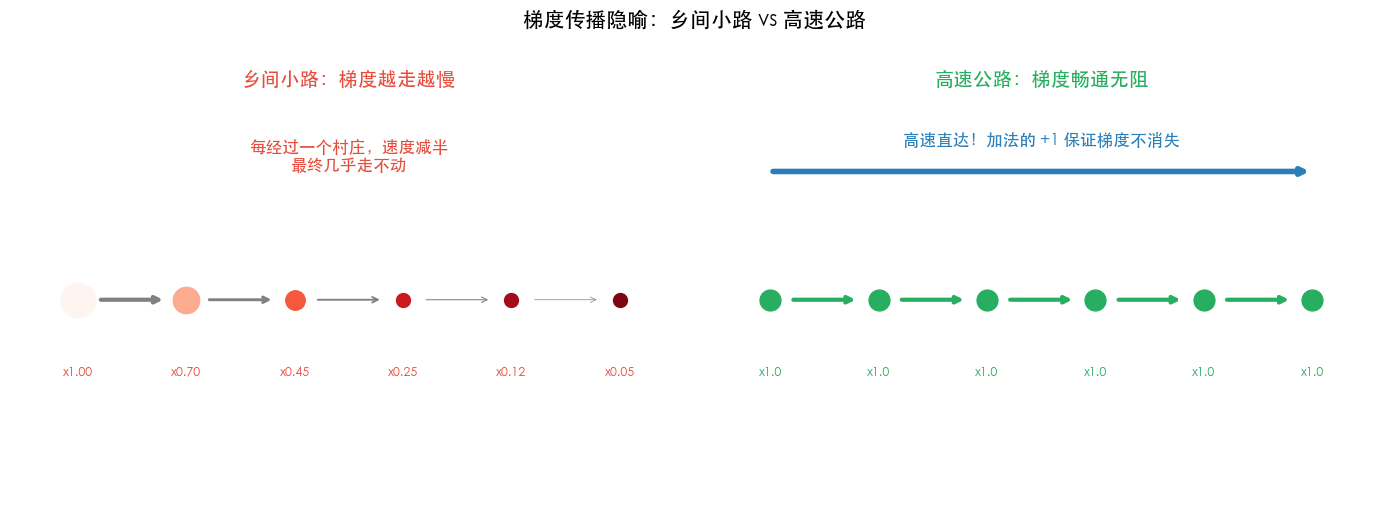</p>*梯度传播隐喻示意图*

## 3. 数学直觉：加法 vs 乘法的梯度传播这是理解残差连接最关键的一点。让我们用最简单的方式解释：### 普通网络：梯度经过乘法

<p align="center">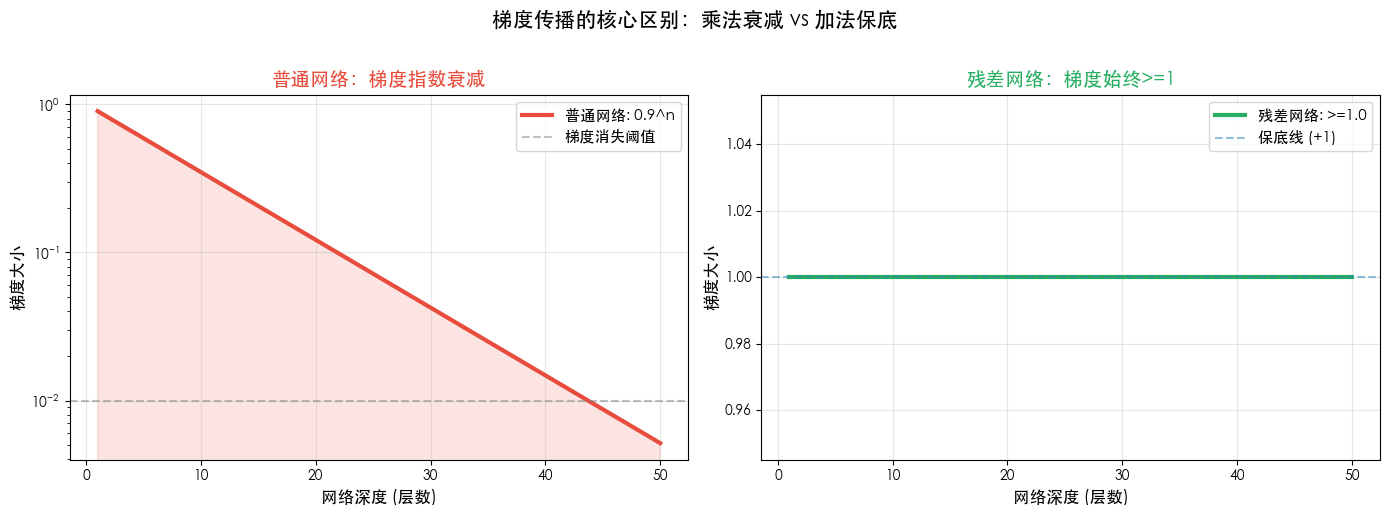</p>*梯度衰减 vs 梯度保底 对比图*

y = f3(f2(f1(x)))

反向传播时，梯度要经过三次乘法：

∂L/∂x = ∂L/∂y × f3' × f2' × f1'

如果每一步的导数都小于 1（比如 0.5），经过三层后梯度变成 0.5^3 = 0.125。经过 50 层呢？0.5^50 ≈ 0。梯度消失了。### 残差网络：梯度经过加法

y = f3(x) + x = F3(x) + x

对 x 求导：

∂y/∂x = F3'(x) + 1

注意这个 **+1**！无论 F3'(x) 有多小，∂y/∂x 至少等于 1。梯度不会消失！这就是残差连接的核心魔法：**加法的导数自带一个 +1，保证了梯度至少以原始大小传播。**---

## 4. 代码实验室：追踪梯度的传播### 4.1 准备工作

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.2 构建可追踪梯度的网络

In [ ]:
class GradientTrackerPlain(nn.Module):    """可追踪每层梯度的普通网络"""    def __init__(self, num_layers=20, hidden_size=32):        super().__init__()        self.layers = nn.ModuleList()        for _ in range(num_layers):            self.layers.append(nn.Sequential(                nn.Linear(hidden_size, hidden_size),                nn.BatchNorm1d(hidden_size),                nn.ReLU(),            ))        self.output_layer = nn.Linear(hidden_size, 1)        self.layer_gradients = []    def forward(self, x):        for layer in self.layers:            x = layer(x)        x = torch.sigmoid(self.output_layer(x))        return x    def capture_gradients(self):        self.layer_gradients = []        for layer in self.layers:            if layer[0].weight.grad is not None:                self.layer_gradients.append(layer[0].weight.grad.norm().item())class GradientTrackerResidual(nn.Module):    """可追踪每层梯度的残差网络"""    def __init__(self, num_layers=20, hidden_size=32):        super().__init__()        self.layers = nn.ModuleList()        for _ in range(num_layers):            self.layers.append(nn.Sequential(                nn.Linear(hidden_size, hidden_size),                nn.BatchNorm1d(hidden_size),            ))        self.output_layer = nn.Linear(hidden_size, 1)        self.layer_gradients = []    def forward(self, x):        for layer in self.layers:            residual = x            x = layer(x)            x = F.relu(x + residual)        x = torch.sigmoid(self.output_layer(x))        return x    def capture_gradients(self):        self.layer_gradients = []        for layer in self.layers:            if layer[0].weight.grad is not None:                self.layer_gradients.append(layer[0].weight.grad.norm().item())

### 4.3 追踪梯度

In [ ]:
def track_gradients(model, X, y, num_steps=50):    """训练模型并追踪每一步的梯度"""    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)    loss_fn = nn.BCELoss()    gradient_history = []    for step in range(num_steps):        pred = model(X)        loss = loss_fn(pred, y)        optimizer.zero_grad()        loss.backward()        model.capture_gradients()        gradient_history.append(model.layer_gradients.copy())        optimizer.step()    return gradient_historynp.random.seed(42)n = 200X_simple = torch.randn(n, 32)y_simple = (X_simple[:, 0] + X_simple[:, 1] > 0).float().unsqueeze(1)torch.manual_seed(42)plain_tracker = GradientTrackerPlain(num_layers=20)plain_grad_history = track_gradients(plain_tracker, X_simple, y_simple, num_steps=50)torch.manual_seed(42)res_tracker = GradientTrackerResidual(num_layers=20)res_grad_history = track_gradients(res_tracker, X_simple, y_simple, num_steps=50)

### 4.4 可视化：梯度在层间的分布

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))plain_final = plain_grad_history[-1]res_final = res_grad_history[-1]layer_indices = list(range(1, len(plain_final) + 1))axes[0].bar(layer_indices, plain_final, color='#e74c3c', alpha=0.8)axes[0].set_xlabel('层编号 (1=最靠近输入)', fontsize=12)axes[0].set_ylabel('梯度范数', fontsize=12)axes[0].set_title('普通网络：梯度在深层消失', fontsize=14)axes[0].grid(True, alpha=0.3, axis='y')axes[1].bar(layer_indices, res_final, color='#2ecc71', alpha=0.8)axes[1].set_xlabel('层编号 (1=最靠近输入)', fontsize=12)axes[1].set_ylabel('梯度范数', fontsize=12)axes[1].set_title('残差网络：梯度在各层保持', fontsize=14)axes[1].grid(True, alpha=0.3, axis='y')plt.tight_layout()plt.show()

### 解读- **普通网络**（红色）：靠近输入层的梯度范数很小——梯度消失了- **残差网络**（绿色）：各层的梯度范数相对均匀——梯度"畅通无阻"这就是残差连接被称为"梯度高速公路"的原因。---

## 5. 梯度流的热力图让我们用热力图更直观地展示梯度随训练步骤的变化：

In [ ]:
plain_array = np.array(plain_grad_history)res_array = np.array(res_grad_history)fig, axes = plt.subplots(1, 2, figsize=(14, 6))im0 = axes[0].imshow(plain_array.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')axes[0].set_xlabel('训练步骤', fontsize=12)axes[0].set_ylabel('层编号', fontsize=12)axes[0].set_title('普通网络：梯度热力图', fontsize=14)plt.colorbar(im0, ax=axes[0], label='梯度范数')im1 = axes[1].imshow(res_array.T, aspect='auto', cmap='YlGn', interpolation='nearest')axes[1].set_xlabel('训练步骤', fontsize=12)axes[1].set_ylabel('层编号', fontsize=12)axes[1].set_title('残差网络：梯度热力图', fontsize=14)plt.colorbar(im1, ax=axes[1], label='梯度范数')plt.tight_layout()plt.show()

### 解读- **普通网络**：热力图底部（靠近输入层）颜色很浅——梯度几乎为零- **残差网络**：热力图颜色相对均匀——各层都能收到足够的梯度信号热力图直观地展示了：残差连接为梯度开辟了一条"高速公路"，让梯度可以畅通无阻地传播到每一层。---

## 6. 核心原理总结：加法的魔力让我们用代码验证"加法不改变梯度大小"这个核心原理：

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)y_multiply = x * 0.5y_multiply.sum().backward()print(f"乘法路径: y = x * 0.5")print(f"  梯度: {x.grad.tolist()}")print(f"  梯度被缩小了一半！")print()x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)y_residual = F.relu(x) + xy_residual.sum().backward()print(f"残差路径: y = relu(x) + x")print(f"  梯度: {x.grad.tolist()}")print(f"  梯度至少为 1！加法的 +1 保证了梯度不消失")

### 解读- **乘法路径**：梯度 = 0.5，被缩小了- **残差路径**：梯度 ≥ 1，加法的 +1 保证了梯度不会消失这就是为什么残差连接被称为"梯度高速公路"——它让梯度可以畅通无阻地传播到网络的每一层。---

## 今日结语今天我们从梯度的角度深入理解了残差连接的有效性：1. **梯度消失的本质**：梯度在乘法链中不断缩小2. **残差连接的魔力**：加法的导数自带 +1，保证梯度至少以原始大小传播3. **代码验证**：残差网络中各层的梯度范数远比普通网络均匀4. **热力图证据**：残差连接为梯度开辟了"高速公路"残差连接不仅仅是一个"技巧"——它从根本上改变了梯度在深层网络中的流动方式。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 乡间小路——越走越慢 | 梯度消失——梯度在乘法链中不断缩小 || 高速公路——直达目的地 | 梯度高速公路——残差连接让梯度畅通无阻 || 公司管理链——信息逐级衰减 | 反向传播——梯度逐层传递 || 直通电话——跳过中间层 | 跳跃连接——梯度可以直接传到前面 || 乘法让东西变小 | 乘法链式法则导致梯度消失 || 加法保底——至少不会更差 | 加法的导数 +1 保证梯度不消失 || 热力图底部颜色浅 | 靠近输入层的梯度很小 || 热力图颜色均匀 | 各层梯度分布均匀 |